<a href="https://colab.research.google.com/github/kpate18/ECGR-4105/blob/main/homework%202/Problem_1(a).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

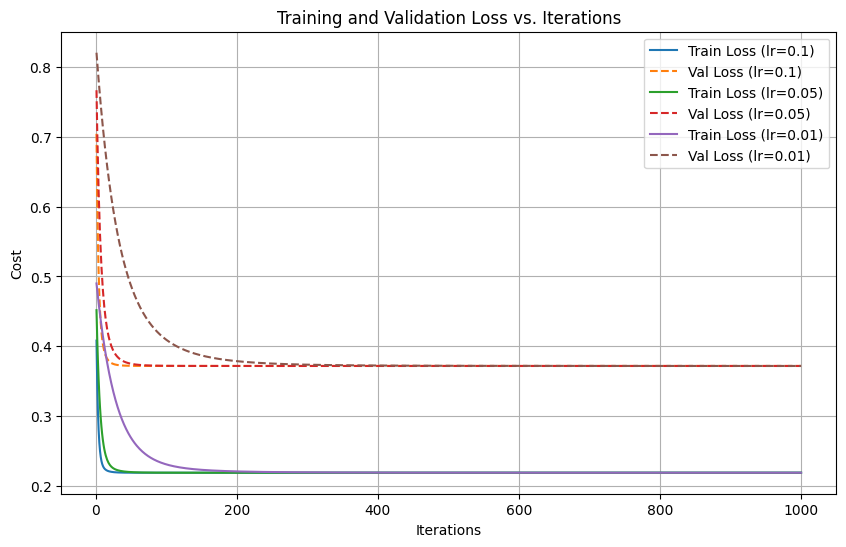

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Housing.csv')

features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
X = df[features].values
y = df['price'].values.reshape(-1, 1)

X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(X, y, test_size=0.20, random_state=42)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_val_scaled = scaler_X.transform(X_val_raw)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_raw)
y_val_scaled = scaler_y.transform(y_val_raw)

X_train = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_val = np.c_[np.ones((X_val_scaled.shape[0], 1)), X_val_scaled]

def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1 / (2 * m)) * np.sum(np.square(predictions - y))
    return cost

def gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations):
    m_train = len(y_train)
    train_loss_history = np.zeros(iterations)
    val_loss_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = X_train.dot(theta)
        errors = predictions - y_train
        gradients = (1 / m_train) * X_train.T.dot(errors)
        theta = theta - alpha * gradients

        train_loss_history[i] = compute_cost(X_train, y_train, theta)
        val_loss_history[i] = compute_cost(X_val, y_val, theta)

    return theta, train_loss_history, val_loss_history

learning_rates = [0.1, 0.05, 0.01]
iterations = 1000

plt.figure(figsize=(10, 6))

for alpha in learning_rates:
    theta_init = np.zeros((X_train.shape[1], 1))
    theta, train_loss, val_loss = gradient_descent(X_train, y_train_scaled, X_val, y_val_scaled, theta_init, alpha, iterations)

    plt.plot(range(1, iterations + 1), train_loss, label=f'Train Loss (lr={alpha})')
    plt.plot(range(1, iterations + 1), val_loss, label=f'Val Loss (lr={alpha})', linestyle='--')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Training and Validation Loss vs. Iterations')
plt.legend()
plt.grid(True)
plt.show()